In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import pylab as pl
import pandas as pd
import scipy.interpolate as sciint
from math import radians, cos
from matplotlib.gridspec import GridSpec

In [2]:
project='realBathy'
ed='run1/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag50'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag50'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid50'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

umbral=int(ny*0.45) # two Bumps int(ny*0.3)

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

start=np.where(ds.T/(60*60*24*360)>0.1)[0][0]
end = np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1]

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [3]:
start=np.where(ds.T/(60*60*24*360)>1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=60)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [4]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    tempIn=np.full(shape=np.shape(ds.THETA[i].values), fill_value=np.nan)
    tempIn[np.where(mask==False)]=ds.THETA[i].values[np.where(mask==False)]
    RHO[i,:,:,:]=999.8*(1-(tempIn-14)*alpha)

In [5]:
drho=np.zeros(np.shape(ds.THETA[:,1:,:,:].values))
rhoprof=np.zeros(np.shape(ds.THETA[:,1:,:,:].values))
for i in range(len(ds.T)):
    drho[i]=(RHO[i,1:,:,:]-RHO[i,:-1,:,:])/(dsG.Z.values[None,1:,None,None]-dsG.Z.values[None,:-1,None,None])
    rhoprof[i]=(RHO[i,1:,:,:]+RHO[i,:-1,:,:])/2
g=9.81
Nf2=-(g/rhoprof)*drho
Nf2[Nf2<0]=np.nan
Nf=np.nanmean(np.sqrt(Nf2),axis=1)

zf=(dsG.Z[1:].values+dsG.Z[:-1].values)/2

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_3110/3175851444.py:9: RuntimeWarning: Mean of empty slice
  Nf=np.nanmean(np.sqrt(Nf2),axis=1)


In [11]:
np.shape(Nf2)

(20, 79, 504, 40)

In [6]:
H=dsG.Depth.values

In [7]:
Cn = Nf*H[None,:,:]/np.pi
Cn[Cn==0]=np.nan

In [8]:
Yin=dsG.Y
Xin=dsG.X
gridY,gridX=np.meshgrid(Yin.values,Xin.values)

V=np.zeros((len(ds.T),len(zf),len(Yin),len(Xin)))
U=np.zeros((len(ds.T),len(zf),len(Yin),len(Xin)))
UtotDif=np.zeros((len(ds.T),len(zf),len(Yin),len(Xin)))

for i in range(len(ds.T)):
    for l in range(len(zf)):
        interpVup=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[i,l].values)
        interpVdow=sciint.RegularGridInterpolator((dsG.Yp1.values,dsG.X.values),ds.VVEL[i,l+1].values)
        Vup=interpVup((gridY,gridX))
        Vdow=interpVdow((gridY,gridX))
        Vdif=Vup-Vdow
        V[i,l,:,:]=(Vup+Vdow).T/2
    
        interpUup=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[i,l].values)
        interpUdow=sciint.RegularGridInterpolator((dsG.Y.values,dsG.Xp1.values),ds.UVEL[i,l+1].values)
        Uup=interpUup((gridY,gridX))
        Udow=interpUdow((gridY,gridX))
        U[i,l,:,:]=(Uup+Udow).T/2
        
        UtotUp=np.sqrt(Uup**2+Vup**2)
        UtotDow=np.sqrt(Udow**2+Vdow**2)
        UtotDif[i,l,:,:]=(UtotUp-UtotDow).T



In [9]:
step=1
depth=np.zeros((len(dsG.Y),len(dsG.X[1:-1])))
avvel=np.zeros((len(dsG.Y),len(dsG.X[1:-1])))
avvelMax=np.zeros((len(dsG.Y),len(dsG.X[1:-1])))
for p in range(len(dsG.Y)):
    for i in np.arange(1,len(dsG.X)-1,1):
        if np.any(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)==False:
             depth[p,i-1]=np.nan
             avvel[p,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,p,i],axis=0),mask=mask[:,p,i]))
             avvelMax[p,i-1]=np.max(np.ma.masked_array(np.mean(ds.VVEL[start:,:,p,i],axis=0),mask=mask[:,p,i]))
        else:
            inddep=np.where(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)[0][-1]
            depth[p,i-1]=dsG.Z[inddep]
            avvel[p,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=mask[inddep:,p,i]))
            avvelMax[p,i-1]=np.max(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=mask[inddep:,p,i]))


KeyboardInterrupt: 

##### Calculate phase velocity of internal waves using n2. $Cn = NH/\pi$
##### Calculate Froude number $Fr=U/(NH/\pi)$ using L as the hydraulic depth (crosssectional area/free surface width)

In [ ]:
Utot=np.sqrt(U**2+V**2)

In [ ]:
shear=UtotDif/(dsG.Z[1:].values-dsG.Z[:-1].values)[None,:,None,None]
shear[shear==0]=np.nan

In [13]:
Fr=Utot/Cn


ValueError: operands could not be broadcast together with shapes (53,79,320,40) (53,320,40) 

In [22]:
np.shape(avvel[umbral:])

(176, 38)

In [26]:
np.max(avvelMax[umbral:]/Cn[-1,umbral:,1:-1])

np.float64(1.3866642384454255)

Text(0, 0.5, 'Froude number')

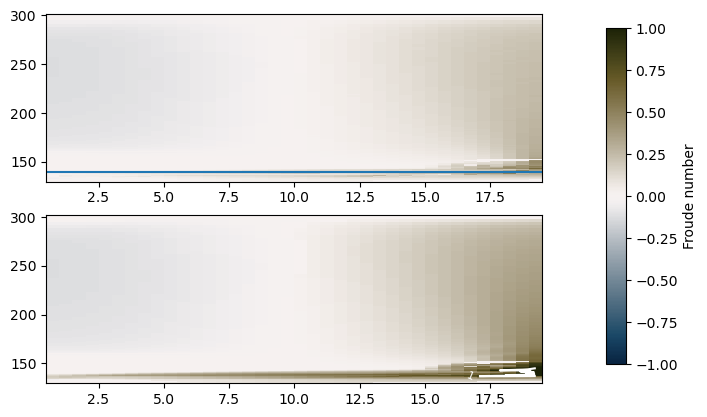

In [20]:
fig,axin = plt.subplots(2)
ax=axin[0]
ax.pcolormesh(dsG.X[1:-1]/1000,dsG.Y[umbral:]/1000,avvel[umbral:]/Cn[-1,umbral:,1:-1],cmap=cmocean.cm.diff,vmin=-1,vmax=1)
caxC=ax.contour(dsG.X[1:-1]/1000,dsG.Y[umbral:]/1000,avvel[umbral:]/Cn[-1,umbral:,1:-1],levels=[1],colors='white')
ax.clabel(caxC, inline=1, fontsize=8)
ax.axhline(dsG.Y[umbral+20]/1000)
ax=axin[1]
cax=ax.pcolormesh(dsG.X[1:-1]/1000,dsG.Y[umbral:]/1000,avvelMax[umbral:]/Cn[-1,umbral:,1:-1],cmap=cmocean.cm.diff,vmin=-1,vmax=1)
caxC=ax.contour(dsG.X[1:-1]/1000,dsG.Y[umbral:]/1000,avvelMax[umbral:]/Cn[-1,umbral:,1:-1],levels=[1],colors='white')
ax.clabel(caxC, inline=1, fontsize=8)
#ax.axhline(dsG.Y[umbral]/1000,color='k')

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax, cax=cbar_ax)
clab='Froude number'
cbar_ax.set_ylabel(clab)

In [12]:
rho0=999.8
Ri=(drho*g)/(rho0*shear**2)

In [13]:
params = {'font.size': 10,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [28]:
np.nanmax(np.mean(Fr[tin,:,:,1:-2],axis=2))

np.float64(0.8723957790339861)

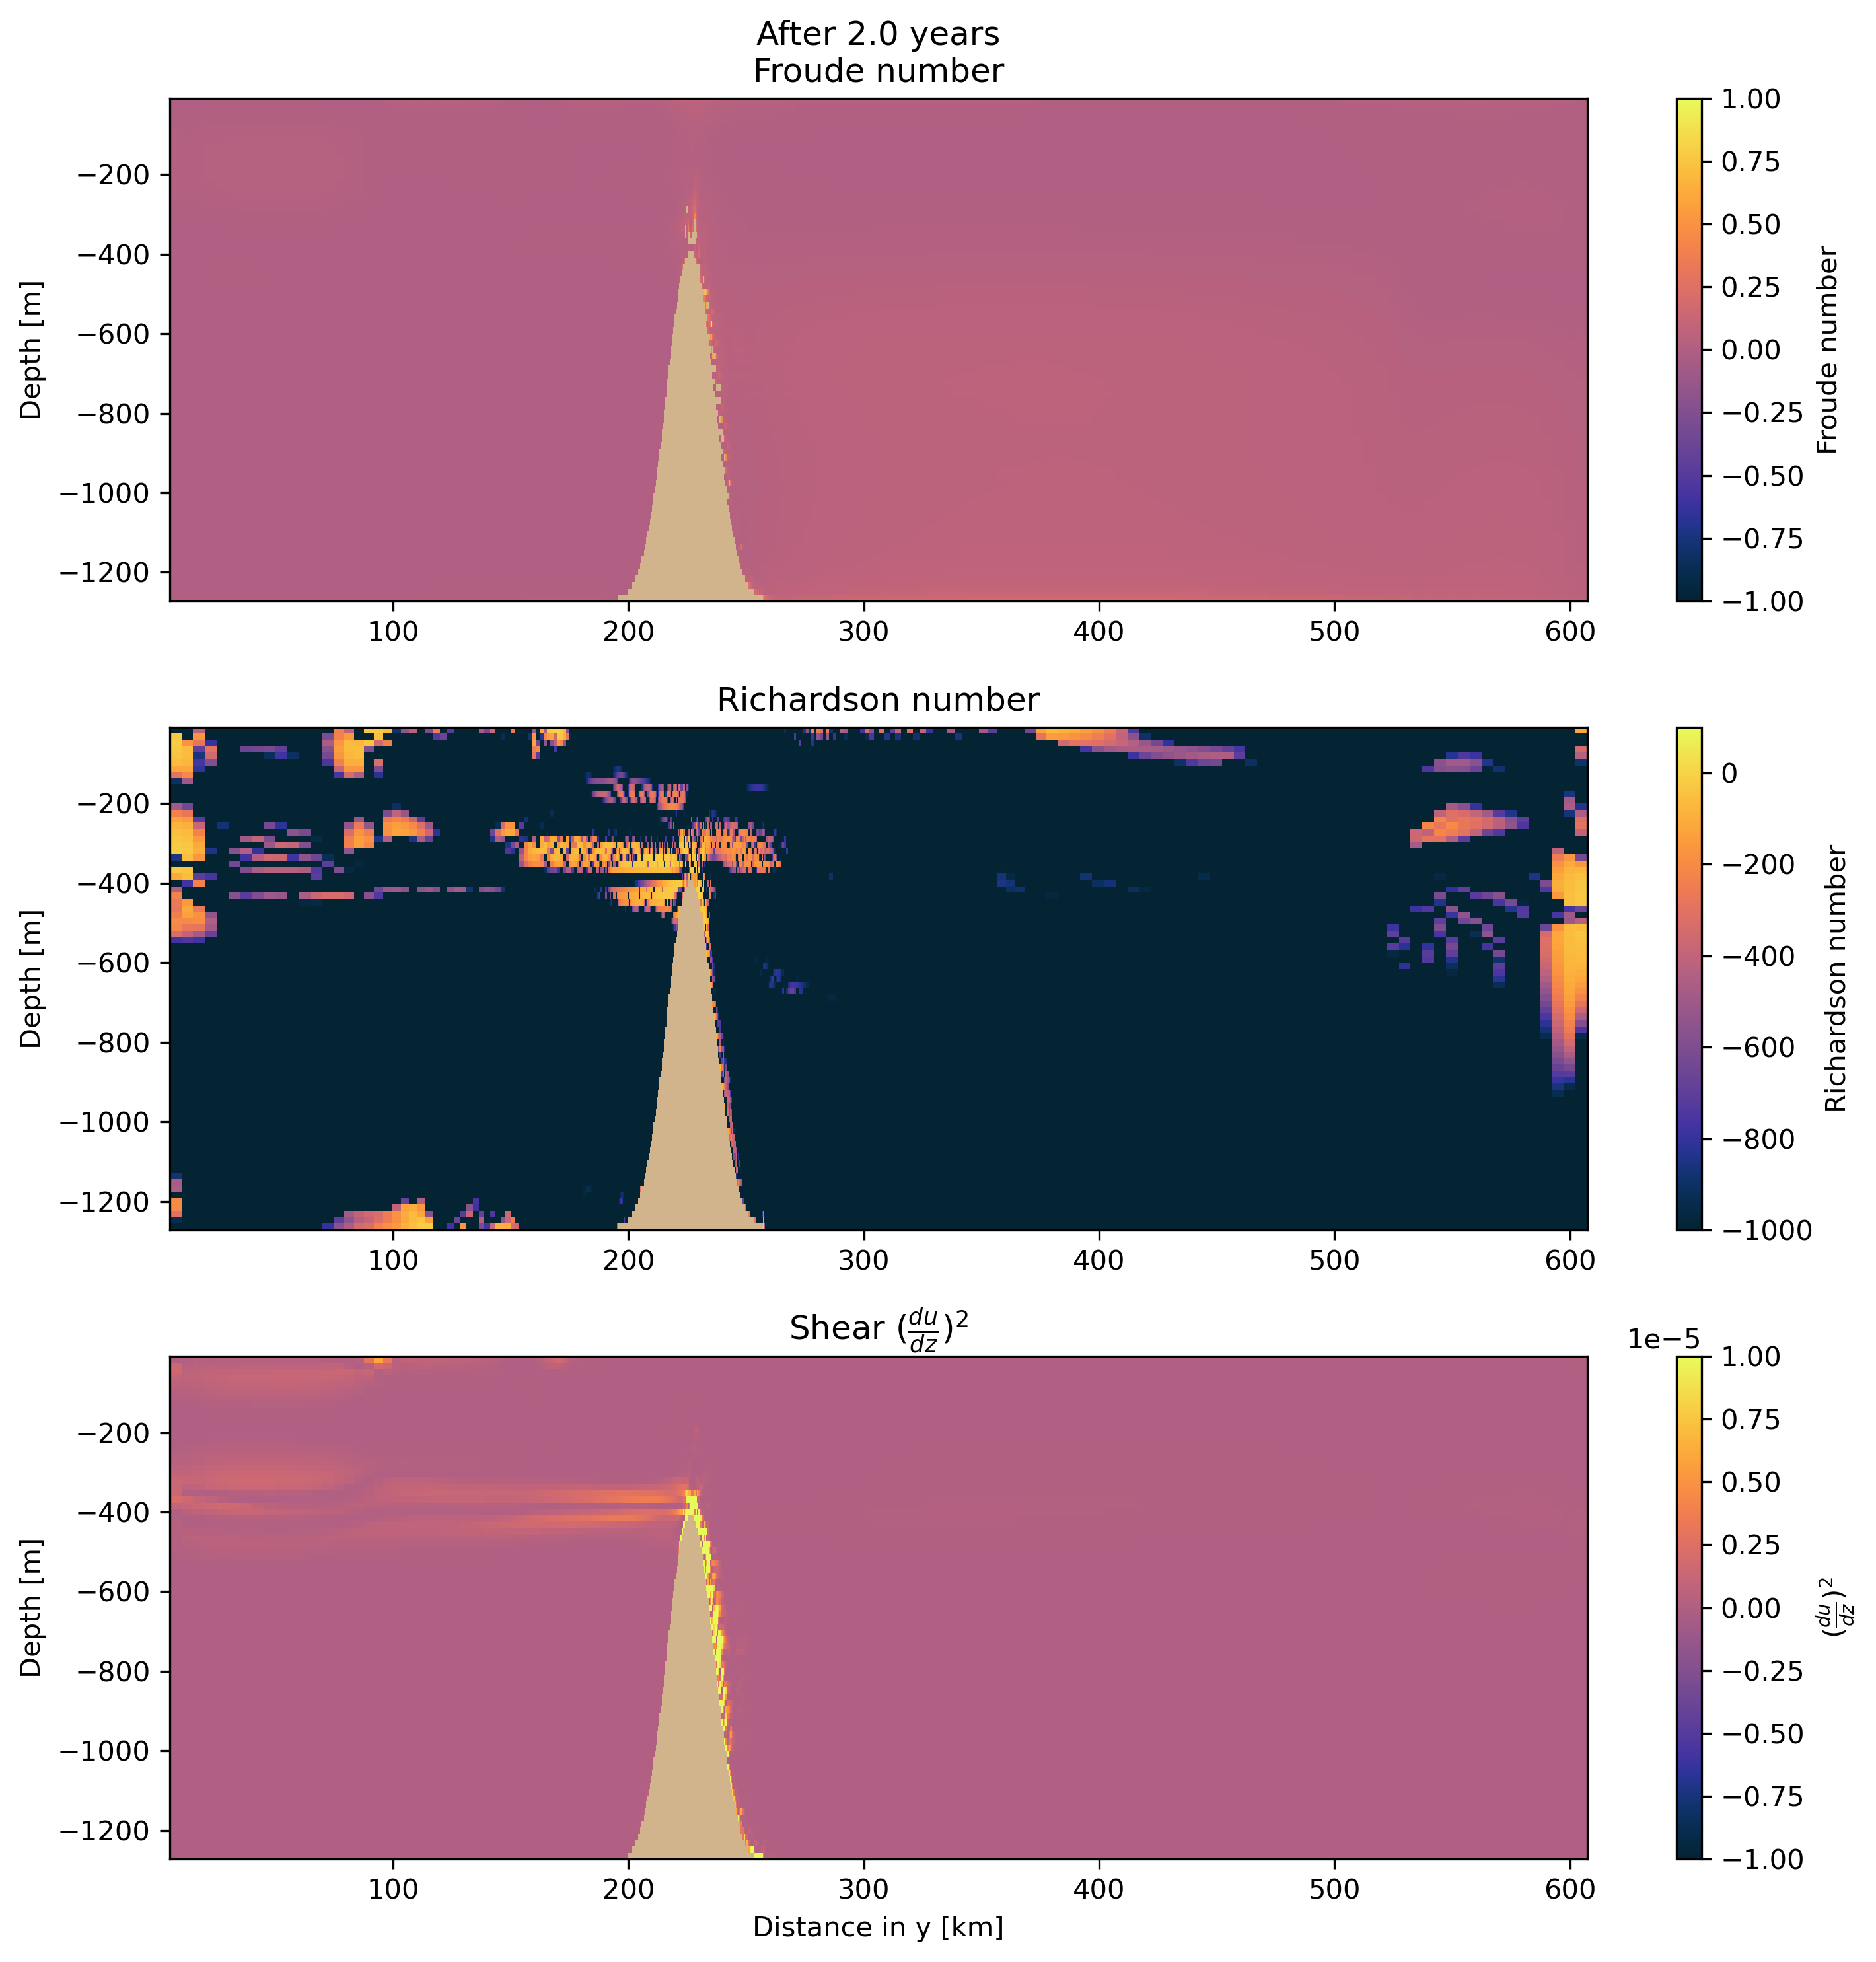

In [22]:
fig,ax = plt.subplots(3)

indX=10
start=0
divT=(60*60*24*360)
unit= 'years'
#Dambreak
tsteps=[20,142] #np.arange(0,len(ds.T),len(ds.T)/10) #np.arange(start,start+len(ds.T[start:end]),len(ds.T[start:end])/10)
#levels=np.arange(14,15.2,0.2)

closS=1#int(ny*0.45)
closE=-1#np.where(dsG.Y>=260000)[0][0]

Yin=dsG.Y[closS:closE]
Zin=zf

cmapi=cmocean.cm.thermal

#---------------------------------------
clab='Froude number'
T=np.mean(Fr[:,:,:,1:-2],axis=3)
vmin=-1 #np.nanmin(T[start,:,OB:OBend])
vmax=1 #np.nanmax(T[start,:,OB:OBend])

axin=ax[0]

tin=int(tsteps[1])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit)+ '\nFroude number',ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=[1],colors='white')
axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax=plt.colorbar(cax0)
cbar_ax.set_label('Froude number')

#---------------------------------------
clab='Richardson number'
T=np.mean(Ri[:,:,:,1:-2],axis=3)

vmin=-1000 #np.nanmin(T[start,:,OB:OBend])
vmax=100 #np.nanmax(T[start,:,OB:OBend])

axin=ax[1]

tin=int(tsteps[1])
timein=(ds.T[tin])/divT 
axin.set(title='Richardson number' ,ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax=plt.colorbar(cax0)
cbar_ax.set_label(clab)

#---------------------------------------

clab=r'$(\frac{du}{dz})^2$'
T=np.mean(shear[:,:,:,1:-2],axis=3)**2

vmin=-1e-5 #np.nanmin(T[start,:,OB:OBend])
vmax=1e-5 #np.nanmax(T[start,:,OB:OBend])

axin=ax[2]
tin=int(tsteps[1])
timein=(ds.T[tin])/divT 
axin.set(ylabel='Depth [m]',title=r'Shear $(\frac{du}{dz})^2$' ,xlabel='Distance in y [km]')
axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax=plt.colorbar(cax0)
cbar_ax.set_label(clab)

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'Criticality.png', bbox_inches='tight')
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 3

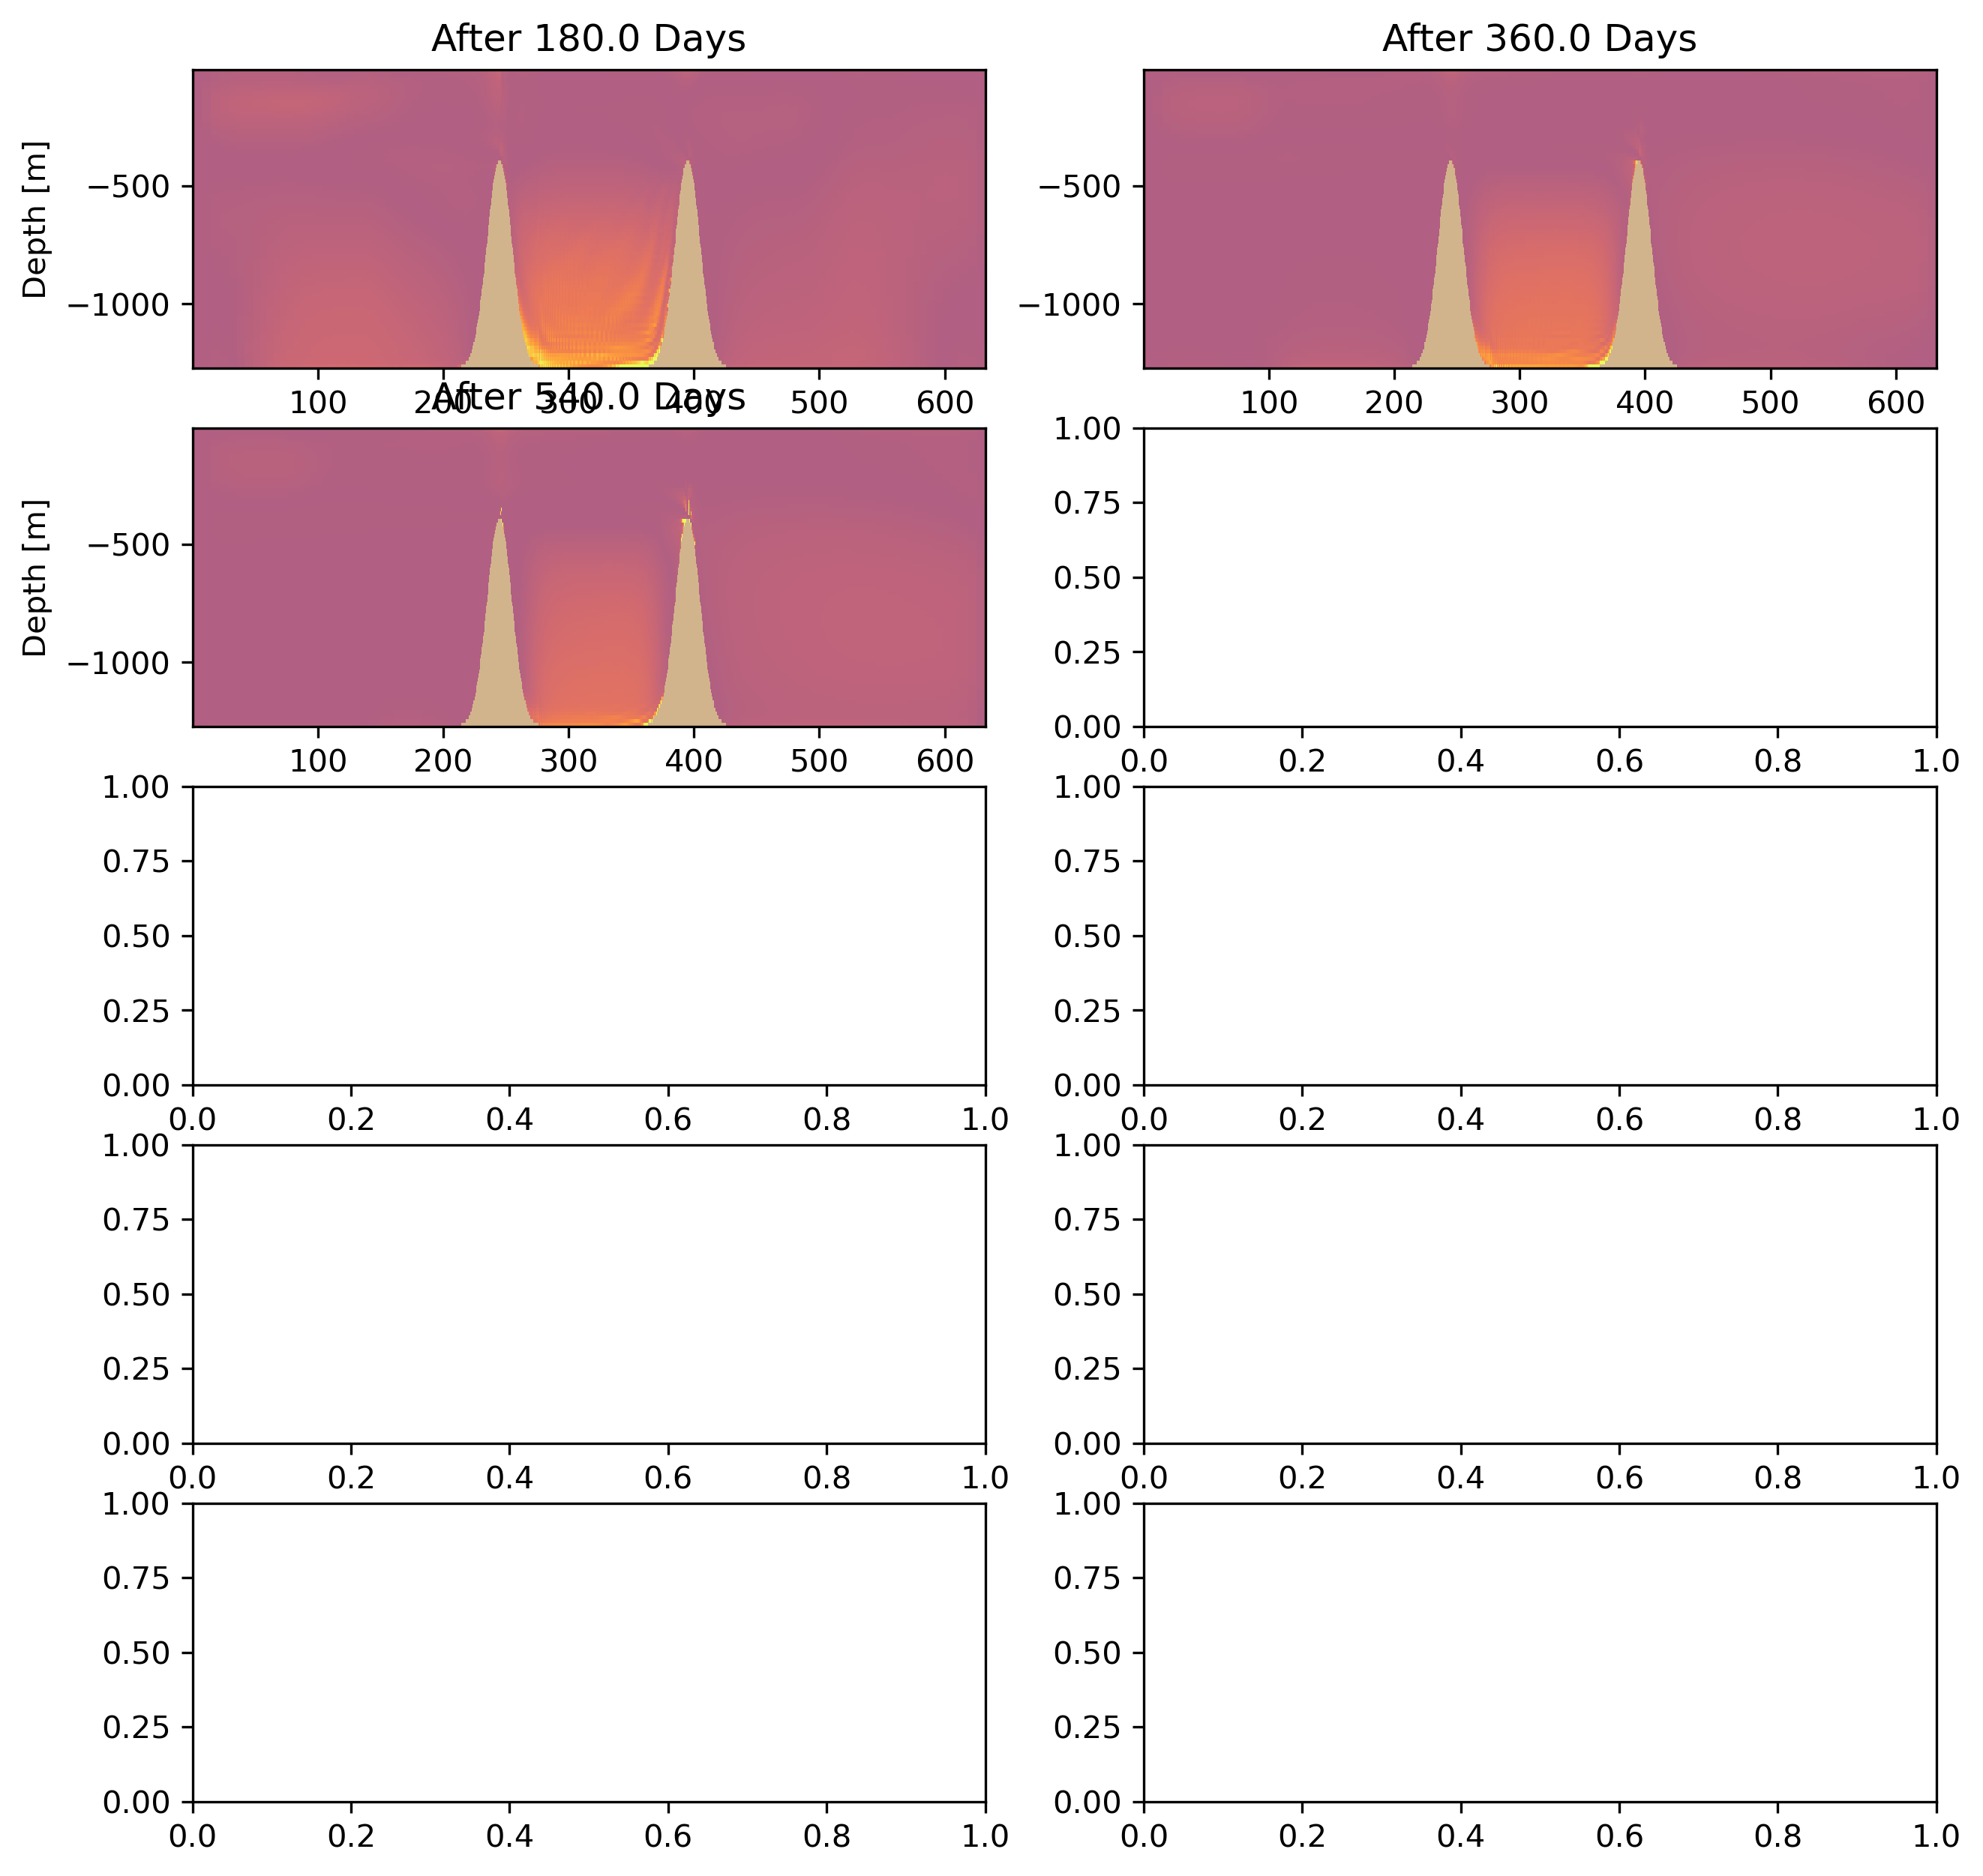

In [25]:
fig,ax = plt.subplots(5,2)

indX=5
start=0
divT=(60*60*24)
unit= 'Days'
#Dambreak
tsteps=[0,1,2,3,4,5,6,34,70,130] #np.arange(0,len(ds.T),len(ds.T)/10) #np.arange(start,start+len(ds.T[start:end]),len(ds.T[start:end])/10)
#levels=np.arange(14,15.2,0.2)

closS=0#int(ny*0.45)
closE=-1#np.where(dsG.Y>=260000)[0][0]


T=Fr[:,:,:,indX]
Yin=dsG.Y[closS:closE]
Zin=zf

vmin=-1 #np.nanmin(T[start,:,OB:OBend])
vmax=1 #np.nanmax(T[start,:,OB:OBend])

cmapi=cmocean.cm.thermal
maskin=mask[:,closS:closE,indX]
#levels=[11,11.5,12,12.5,13,13.5,14,15]
clab='Froude number'



axin=ax[0,0]
tin=int(tsteps[0])
timein=(ds.T[tin])/divT 
axin.set(ylabel='Depth [m]',title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[0,1]

tin=int(tsteps[1])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[1,0]

tin=int(tsteps[2])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[1,1]

tin=int(tsteps[3])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)



axin=ax[2,0]

tin=int(tsteps[4])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[2,1]

tin=int(tsteps[5])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)

axin=ax[3,0]

tin=int(tsteps[6])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[3,1]

tin=int(tsteps[7])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[4,0]

tin=int(tsteps[8])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]',xlabel='Distance in y [km]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)


axin=ax[4,1]

tin=int(tsteps[9])
timein=(ds.T[tin])/divT 
axin.set(title=f'After {timein:.1f} ' + str(unit),xlabel='Distance in y [km]' )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, T[tin,:,closS:closE],vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, T[tin,:,closS:closE],levels=levels,colors='white')
#axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(clab)


fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'Froude.png', bbox_inches='tight')
plt.show()